# Regression Experiments with a NumPy Neural Network

This notebook uses the neural-network framework implemented in `modules/` to predict song release year from the Million Song Dataset audio features. It documents the progression from simple baselines and unstable initial networks to a regularized model that outperforms Ridge regression.

The analysis focuses on experimental reasoning: problem formulation, feature and target scaling, optimizer choice, model capacity, regularization, and hyperparameter selection.

## Setup

In [ ]:
import modules as mm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output

plt.rcParams.update({'font.size': 16})
sns.set_style('whitegrid')
np.random.seed(0xFA1AFE1)

## Dataset

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "YearPredictionMSD.txt.zip"
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00203/YearPredictionMSD.txt.zip"
)

if not DATA_PATH.exists():
    urlretrieve(DATA_URL, DATA_PATH)


In [ ]:
df = pd.read_csv(DATA_PATH, header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Range: 1922 - 2011
Unique values: 89


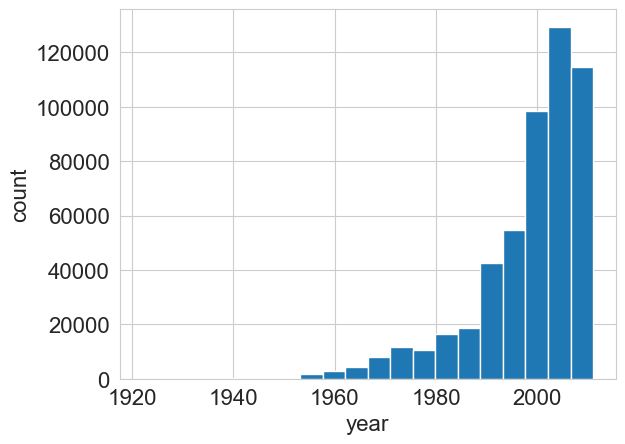

In [ ]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Baselines

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge()
ridge.fit(X_train, y_train)
train_predict_ridge = ridge.predict(X_train)
test_predict_ridge = ridge.predict(X_test)
train_mse_ridge = mean_squared_error(y_train, train_predict_ridge)
test_mse_ridge = mean_squared_error(y_test, test_predict_ridge)
print('Ridge train MSE:', train_mse_ridge)
print('Ridge test MSE:', test_mse_ridge)

Ridge train MSE: 91.6651149451265
Ridge test MSE: 89.74966397222087


## Constant baseline

Under squared error, the optimal constant prediction is the mean of the training targets:

$$c^*=\arg\min_c \frac{1}{N}\sum_i(y_i-c)^2=\frac{1}{N}\sum_i y_i.$$

The constant baseline establishes the minimum standard that a learned model should exceed.

In [ ]:
best_constant = np.mean(y_train)
train_predict_constant = np.full(y_train.shape, best_constant)
test_predict_constant = np.full(y_test.shape, best_constant)
train_mse_constant = mean_squared_error(y_train, train_predict_constant)
test_mse_constant = mean_squared_error(y_test, test_predict_constant)
print('Best constant:', best_constant)
print('Constant train MSE:', train_mse_constant)
print('Constant test MSE:', test_mse_constant)

Best constant: 1998.3753660985026
Constant train MSE: 120.10875618537533
Constant test MSE: 117.62580230734426


## Validation protocol

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Training and evaluation utilities

In [ ]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label='train')
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label='val')

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if max(train_metrics) / min(train_metrics) > 10:
        axs[0].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('MSE')
    plt.show()


def train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True):
    """
    Train and validate neural network
      - model: neural network (mm.Module) to train
      - optimizer: optimizer (mm.Optimizer) chained to a model
      - criterion: loss function class (mm.Criterion)
      - metrics: function to measure MSE taking neural networks predictions
                 and ground truth labels
      - train_loader: mm.DataLoader with train set
      - val_loader: mm.DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}') \
            if verbose else train_loader

        for X_batch, y_batch in pbar:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            grad_predictions = criterion.backward(predictions, y_batch)
            model.backward(X_batch, grad_predictions)
            optimizer.step()

            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        train_losses += [running_loss / train_loader.num_samples()]
        train_metrics += [running_metric / train_loader.num_samples()]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = tqdm(val_loader, desc=f'Validating {epoch}/{num_epochs}') \
            if verbose else val_loader

        for X_batch, y_batch in pbar:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        val_losses += [running_loss / val_loader.num_samples()]
        val_metrics += [running_metric / val_loader.num_samples()]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    
    if verbose:
        print(f'Validation MSE: {val_metrics[-1]:.3f}')
    
    return train_metrics[-1], val_metrics[-1]

## Formulating the prediction problem

In [ ]:
from tqdm import tqdm

Validation MSE: 195.308


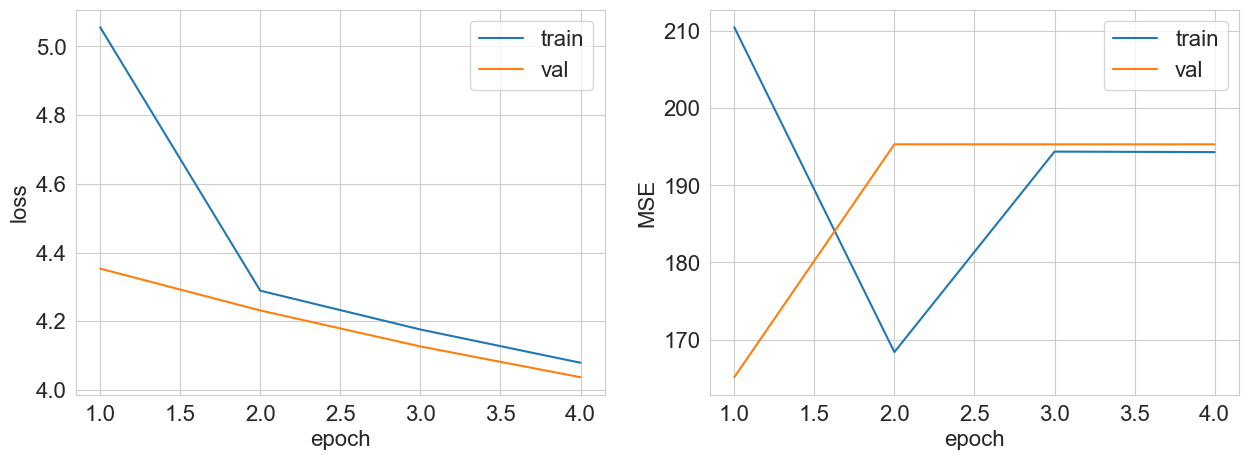

In [ ]:
years = np.unique(np.concatenate([y_train, y_val]))
num_classes = len(years)
y_train_classes = np.searchsorted(years, y_train)
y_val_classes = np.searchsorted(years, y_val)

batch_size = 64

train_loader = mm.DataLoader(
    X_train,
    y_train_classes,
    batch_size=batch_size,
    shuffle=True
)

val_loader = mm.DataLoader(
    X_val,
    y_val_classes,
    batch_size=batch_size,
    shuffle=False
)

model = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, num_classes)
)

criterion = mm.CrossEntropyLoss()
optimizer = mm.SGD(model, lr=1e-3)

metric = lambda predictions, targets: np.mean(
    (
        years[np.argmax(predictions, axis=1)]
        - years[targets]
    ) ** 2
)

train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    metric=metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4
)


### Classification formulation

Treating each release year as an independent class performs poorly: validation MSE is approximately **195.3**, worse than the Ridge baseline. The formulation ignores the ordinal structure of years—a one-year error is penalized exactly like a several-decade error during classification training. Regression is therefore the more appropriate formulation.

## Regression and optimization stability

Validation MSE: 348120.892


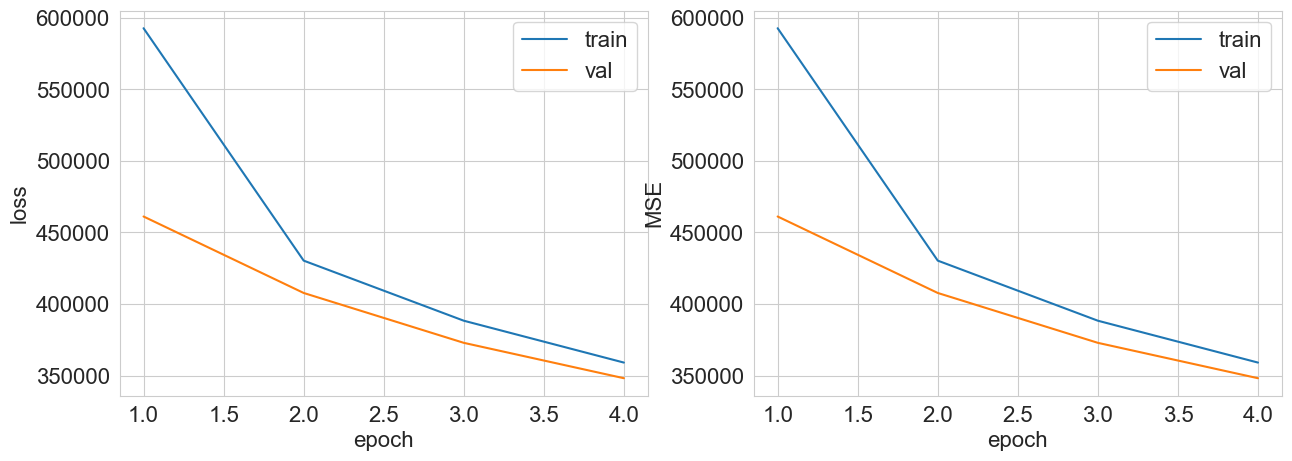

In [ ]:
y_train_reg = y_train.reshape(-1, 1)
y_val_reg = y_val.reshape(-1, 1)

batch_size = 64

train_loader_reg = mm.DataLoader(
    X_train,
    y_train_reg,
    batch_size=batch_size,
    shuffle=True
)

val_loader_reg = mm.DataLoader(
    X_val,
    y_val_reg,
    batch_size=batch_size,
    shuffle=False
)

model_reg = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1)
)

criterion_reg = mm.MSELoss()
optimizer_reg = mm.SGD(model_reg, lr=1e-9)
metric_reg = lambda predictions, targets: np.mean(
    (predictions - targets) ** 2
)

train_mse_reg, val_mse_reg = train_and_validate(
    model=model_reg,
    optimizer=optimizer_reg,
    criterion=criterion_reg,
    metric=metric_reg,
    train_loader=train_loader_reg,
    val_loader=val_loader_reg,
    num_epochs=4
)


### Initial regression instability

Direct regression with unscaled inputs and targets is unstable and produces very large errors. Reducing the learning rate helps only partially. The large target magnitude and heterogeneous feature scales create poorly conditioned gradients, motivating explicit normalization.

## Target normalization

In [ ]:
y_min = np.min(y_train)
y_max = np.max(y_train)

def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - y_min) / (y_max - y_min)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (y_max - y_min) + y_min

Validation MSE: 280.063


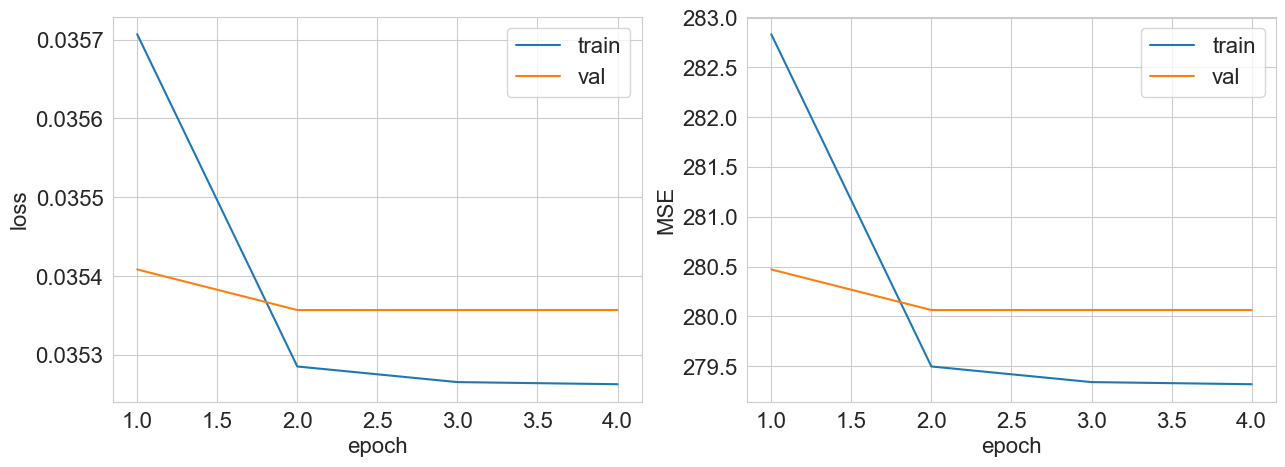

In [ ]:
y_train_reg = normalize(y_train).reshape(-1, 1)
y_val_reg = normalize(y_val).reshape(-1, 1)

batch_size = 64

train_loader_reg = mm.DataLoader(
    X_train,
    y_train_reg,
    batch_size=batch_size,
    shuffle=True
)

val_loader_reg = mm.DataLoader(
    X_val,
    y_val_reg,
    batch_size=batch_size,
    shuffle=False
)

model_reg = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)

criterion_reg = mm.MSELoss()
optimizer_reg = mm.SGD(model_reg, lr=1e-3)

metric_reg = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_reg, val_mse_reg = train_and_validate(
    model=model_reg,
    optimizer=optimizer_reg,
    criterion=criterion_reg,
    metric=metric_reg,
    train_loader=train_loader_reg,
    val_loader=val_loader_reg,
    num_epochs=4
)


### Target normalization

MinMax-normalizing the target and constraining the output with a sigmoid substantially stabilizes optimization. Validation MSE falls from hundreds of thousands in the unstable run to approximately **280**, but performance remains worse than the linear baseline.

## Input-feature standardization

Validation MSE: 108.964


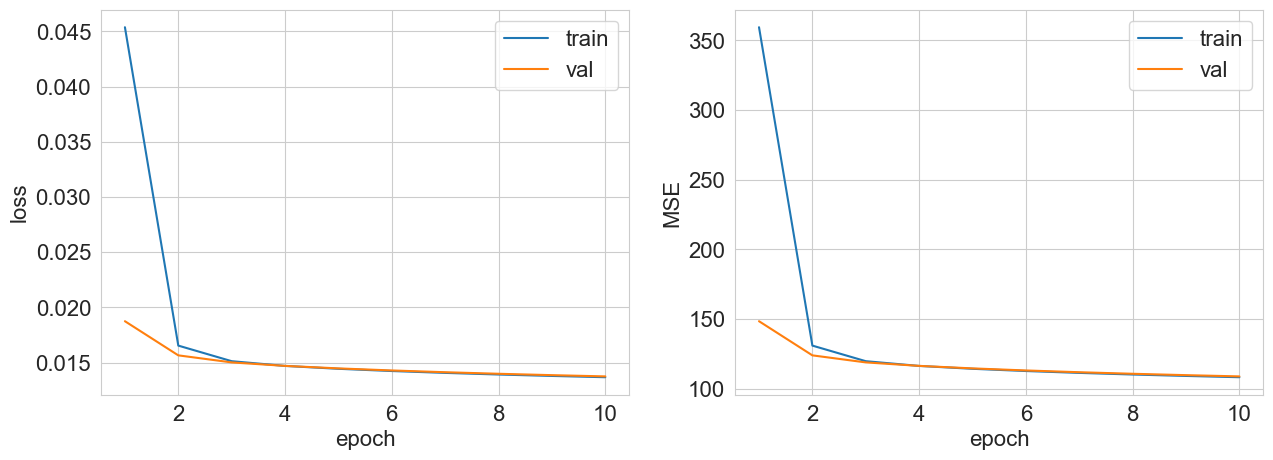

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

y_train_scaled = normalize(y_train).reshape(-1, 1)
y_val_scaled = normalize(y_val).reshape(-1, 1)

batch_size = 64

train_loader_scaled = mm.DataLoader(
    X_train_scaled,
    y_train_scaled,
    batch_size=batch_size,
    shuffle=True
)

val_loader_scaled = mm.DataLoader(
    X_val_scaled,
    y_val_scaled,
    batch_size=batch_size,
    shuffle=False
)

np.random.seed(42)

model_scaled = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)

criterion_scaled = mm.MSELoss()
optimizer_scaled = mm.SGD(model_scaled, lr=1e-3)

metric_scaled = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_scaled, val_mse_scaled = train_and_validate(
    model=model_scaled,
    optimizer=optimizer_scaled,
    criterion=criterion_scaled,
    metric=metric_scaled,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)


### Feature standardization

Standardizing the inputs reduces validation MSE to approximately **109**, close to Ridge. This is the largest single improvement in the early experiments and demonstrates that optimization—not merely model capacity—was the primary initial bottleneck.

## Improving the neural network

### Optimizer selection

Validation MSE: 89.566


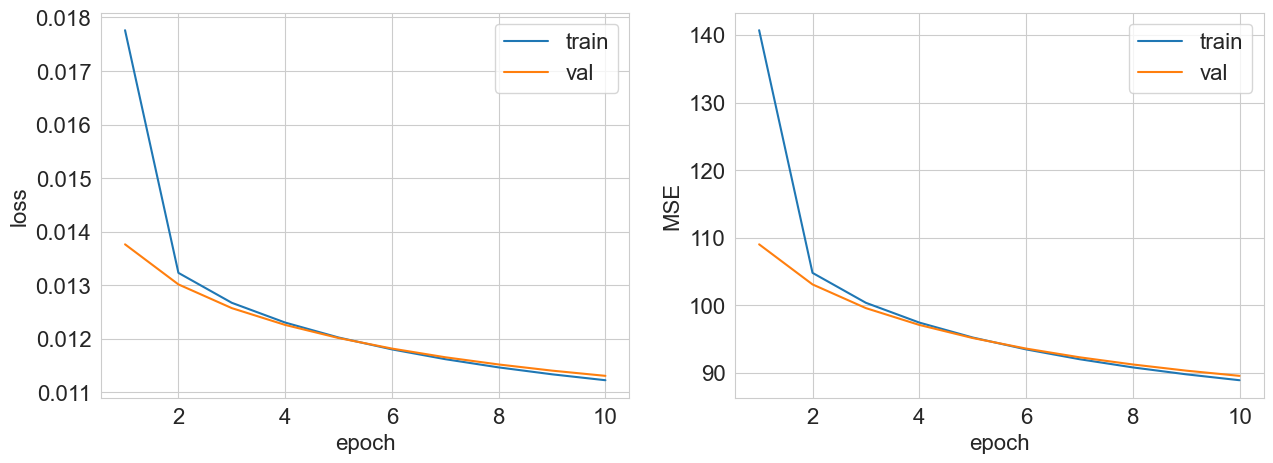

In [ ]:
np.random.seed(42)

model_momentum = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)

criterion_momentum = mm.MSELoss()
optimizer_momentum = mm.SGD(
    model_momentum,
    lr=1e-3,
    momentum=0.9
)

metric_momentum = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_momentum, val_mse_momentum = train_and_validate(
    model=model_momentum,
    optimizer=optimizer_momentum,
    criterion=criterion_momentum,
    metric=metric_momentum,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)


In [ ]:
print('SGD + momentum:')
print('Train MSE:', train_mse_momentum)
print('Validation MSE:', val_mse_momentum)

SGD + momentum:
Train MSE: 88.92006317622757
Validation MSE: 89.5663300709072


Validation MSE: 79.185


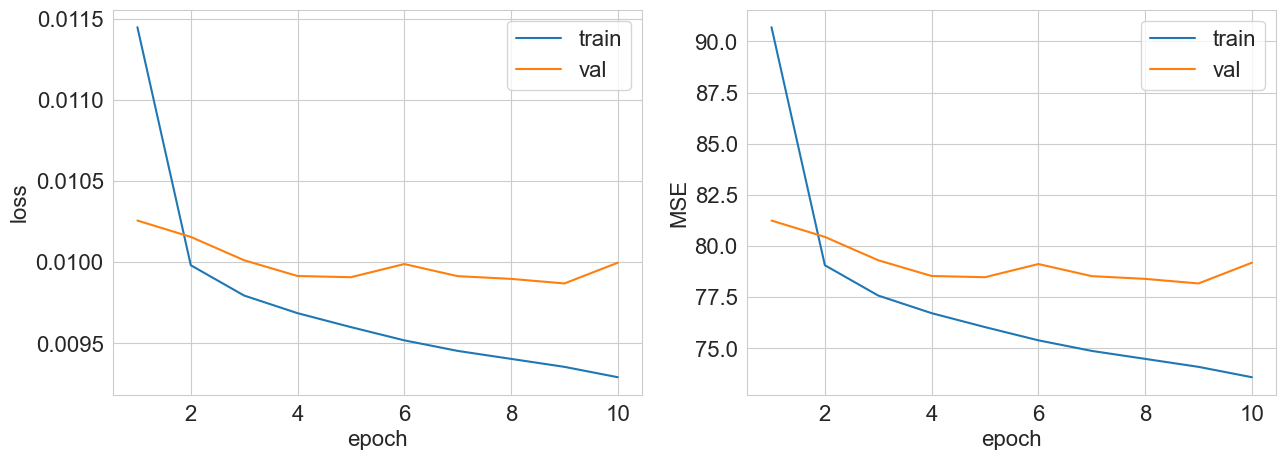

In [ ]:
np.random.seed(42)

model_adam = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)

criterion_adam = mm.MSELoss()
optimizer_adam = mm.Adam(model_adam, lr=1e-3)

metric_adam = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_adam, val_mse_adam = train_and_validate(
    model=model_adam,
    optimizer=optimizer_adam,
    criterion=criterion_adam,
    metric=metric_adam,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)


In [ ]:
print('Adam:')
print('Train MSE:', train_mse_adam)
print('Validation MSE:', val_mse_adam)

Adam:
Train MSE: 73.58998114389385
Validation MSE: 79.18502950361169


### Optimizer comparison

SGD with momentum reaches validation MSE of approximately **89.6**. Adam improves it further to approximately **79.2**, although it creates a slightly larger train–validation gap. Adam is used in the remaining experiments.

### Architecture comparison

Validation MSE: 78.411


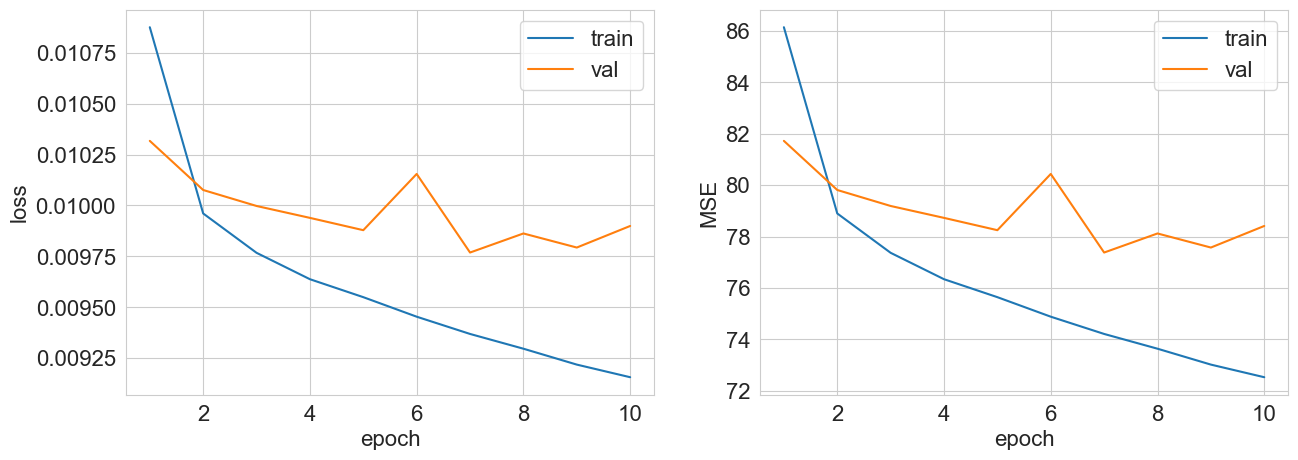

In [ ]:
np.random.seed(42)

model_wide = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 256),
    mm.ReLU(),
    mm.Linear(256, 1),
    mm.Sigmoid()
)

criterion_wide = mm.MSELoss()
optimizer_wide = mm.Adam(model_wide, lr=1e-3)

metric_wide = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_wide, val_mse_wide = train_and_validate(
    model=model_wide,
    optimizer=optimizer_wide,
    criterion=criterion_wide,
    metric=metric_wide,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)


Validation MSE: 76.290


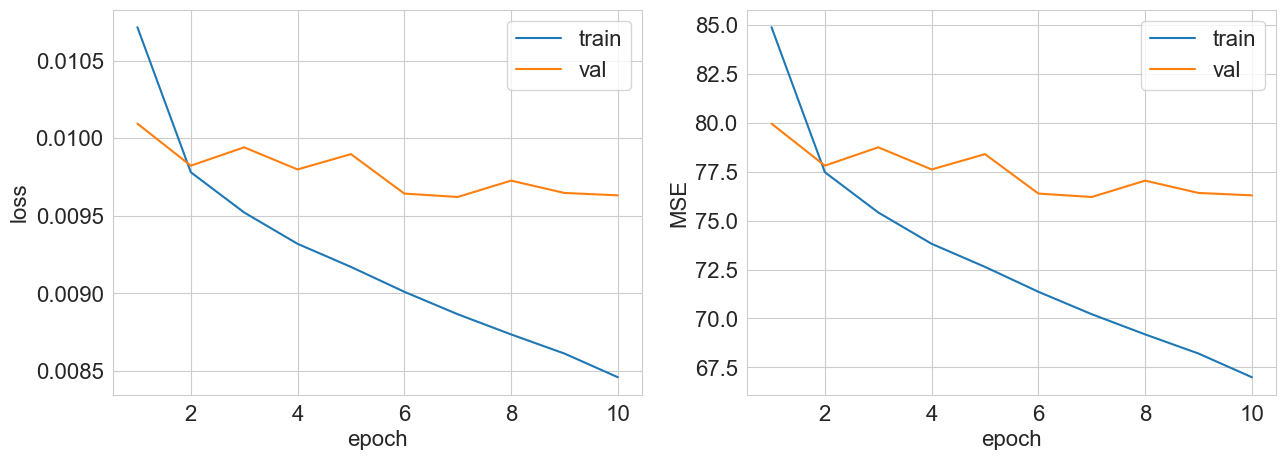

In [ ]:
np.random.seed(42)

model_deep = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)

criterion_deep = mm.MSELoss()
optimizer_deep = mm.Adam(model_deep, lr=1e-3)

metric_deep = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_deep, val_mse_deep = train_and_validate(
    model=model_deep,
    optimizer=optimizer_deep,
    criterion=criterion_deep,
    metric=metric_deep,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)


Validation MSE: 77.805


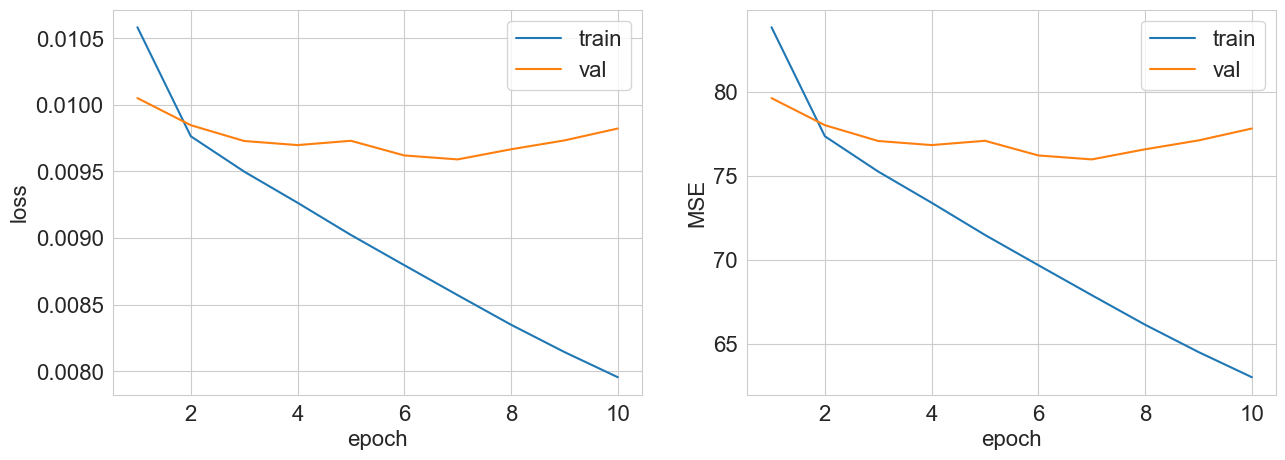

In [ ]:
np.random.seed(42)

model_wide_deep = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 256),
    mm.ReLU(),
    mm.Linear(256, 256),
    mm.ReLU(),
    mm.Linear(256, 1),
    mm.Sigmoid()
)

criterion_wide_deep = mm.MSELoss()
optimizer_wide_deep = mm.Adam(model_wide_deep, lr=1e-3)

metric_wide_deep = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_wide_deep, val_mse_wide_deep = train_and_validate(
    model=model_wide_deep,
    optimizer=optimizer_wide_deep,
    criterion=criterion_wide_deep,
    metric=metric_wide_deep,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)


In [ ]:
print('Base model:')
print('Train MSE:', train_mse_adam)
print('Validation MSE:', val_mse_adam)

print('\nWide model:')
print('Train MSE:', train_mse_wide)
print('Validation MSE:', val_mse_wide)

print('\nDeep model:')
print('Train MSE:', train_mse_deep)
print('Validation MSE:', val_mse_deep)

print('\nWide + deep model:')
print('Train MSE:', train_mse_wide_deep)
print('Validation MSE:', val_mse_wide_deep)

Base model:
Train MSE: 73.58998114389385
Validation MSE: 79.18502950361169
Wide model:
Train MSE: 72.5263046363109
Validation MSE: 78.41079571652249
Deep model:
Train MSE: 66.99833374386739
Validation MSE: 76.28979300074289
Wide + deep model:
Train MSE: 63.01533103283583
Validation MSE: 77.80482293325743


### Width and depth

Increasing width improves validation MSE from **79.19** to **78.41**. A deeper network performs better at **76.29**. Combining additional width and depth lowers training error but slightly worsens validation performance (**77.80**), indicating increased overfitting.

### Regularization experiments

Validation MSE: 75.684


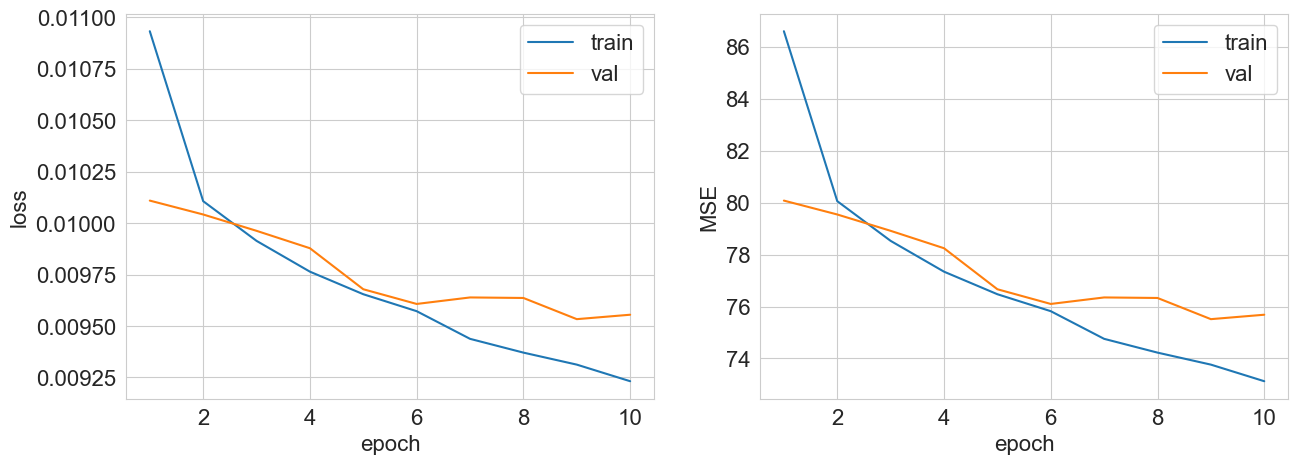

In [ ]:
np.random.seed(42)
model_dropout = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 256),
    mm.ReLU(),
    mm.Dropout(p=0.2),

    mm.Linear(256, 256),
    mm.ReLU(),
    mm.Dropout(p=0.2),

    mm.Linear(256, 1),
    mm.Sigmoid()
)

criterion_dropout = mm.MSELoss()

optimizer_dropout = mm.Adam(
    model_dropout,
    lr=1e-3
)

metric_dropout = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_dropout, val_mse_dropout = train_and_validate(
    model=model_dropout,
    optimizer=optimizer_dropout,
    criterion=criterion_dropout,
    metric=metric_dropout,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)

In [ ]:
print('Dropout model:')
print('Train MSE:', train_mse_dropout)
print('Validation MSE:', val_mse_dropout)

Dropout model:
Train MSE: 73.12356748824874
Validation MSE: 75.68350786834895


Validation MSE: 75.807


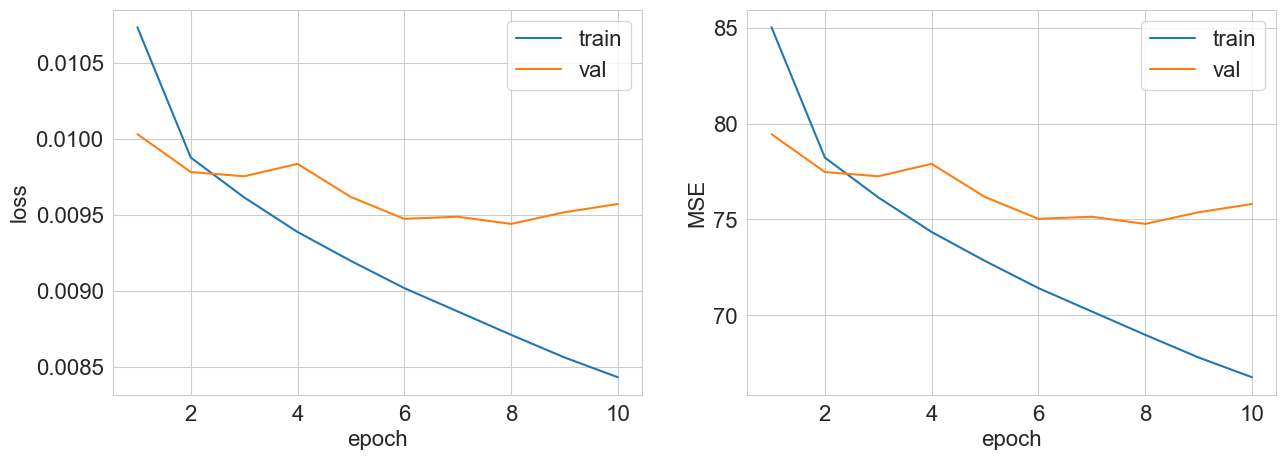

In [ ]:
np.random.seed(42)

model_batchnorm = mm.Sequential(
    mm.Linear(X_train_scaled.shape[1], 256),
    mm.BatchNormalization(256),
    mm.ReLU(),

    mm.Linear(256, 256),
    mm.BatchNormalization(256),
    mm.ReLU(),

    mm.Linear(256, 1),
    mm.Sigmoid()
)

criterion_batchnorm = mm.MSELoss()

optimizer_batchnorm = mm.Adam(
    model_batchnorm,
    lr=1e-3
)

metric_batchnorm = lambda predictions, targets: np.mean(
    (
        denormalize(predictions)
        - denormalize(targets)
    ) ** 2
)

train_mse_batchnorm, val_mse_batchnorm = train_and_validate(
    model=model_batchnorm,
    optimizer=optimizer_batchnorm,
    criterion=criterion_batchnorm,
    metric=metric_batchnorm,
    train_loader=train_loader_scaled,
    val_loader=val_loader_scaled,
    num_epochs=10
)

In [ ]:
print('BatchNorm model:')
print('Train MSE:', train_mse_batchnorm)
print('Validation MSE:', val_mse_batchnorm)

BatchNorm model:
Train MSE: 66.77158068567392
Validation MSE: 75.80705974227227


### Regularization

Dropout increases training MSE but improves validation MSE to **75.68**, substantially narrowing the generalization gap. Batch Normalization produces a similar validation result of **75.81**. Dropout is selected for the final architecture.

## Hyperparameter search

In [ ]:
def create_dropout_model():
    return mm.Sequential(
        mm.Linear(X_train_scaled.shape[1], 256),
        mm.ReLU(),
        mm.Dropout(p=0.2),

        mm.Linear(256, 256),
        mm.ReLU(),
        mm.Dropout(p=0.2),

        mm.Linear(256, 1),
        mm.Sigmoid()
    )

In [ ]:
learning_rates = np.logspace(-4, -2.5, 4)
print(learning_rates)

[0.0001     0.00031623 0.001      0.00316228]


In [ ]:
train_mse_by_lr = []
val_mse_by_lr = []

num_experiments = len(learning_rates)

for experiment_number, lr in enumerate(learning_rates, start=1):
    print(
        f'\nExperiment {experiment_number}/{num_experiments}'
        f'\nLearning rate: {lr:.6f}'
    )

    np.random.seed(42)

    model = create_dropout_model()
    criterion = mm.MSELoss()

    optimizer = mm.Adam(
        model,
        lr=lr
    )

    train_mse, val_mse = train_and_validate(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        metric=metric_dropout,
        train_loader=train_loader_scaled,
        val_loader=val_loader_scaled,
        num_epochs=5,
        verbose=False
    )

    train_mse_by_lr.append(train_mse)
    val_mse_by_lr.append(val_mse)

    current_best_index = np.argmin(val_mse_by_lr)
    current_best_lr = learning_rates[current_best_index]
    current_best_mse = val_mse_by_lr[current_best_index]

    print(
        f'Train MSE: {train_mse:.3f}\n'
        f'Validation MSE: {val_mse:.3f}\n'
        f'Current best lr: {current_best_lr:.6f}\n'
        f'Current best validation MSE: {current_best_mse:.3f}'
    )

best_lr_index = np.argmin(val_mse_by_lr)
best_lr = learning_rates[best_lr_index]

print('Best lr:', best_lr)
print('Best validation MSE:', val_mse_by_lr[best_lr_index])

Experiment 2/4
Learning rate: 0.000316
Train MSE: 75.541
Validation MSE: 75.748
Current best lr: 0.000316
Current best validation MSE: 75.748
Experiment 3/4
Learning rate: 0.001000
Train MSE: 76.473
Validation MSE: 76.664
Current best lr: 0.000316
Current best validation MSE: 75.748
Experiment 4/4
Learning rate: 0.003162
Train MSE: 80.112
Validation MSE: 78.400
Current best lr: 0.000316
Current best validation MSE: 75.748
Best lr: 0.00031622776601683794
Best validation MSE: 75.74835480727629


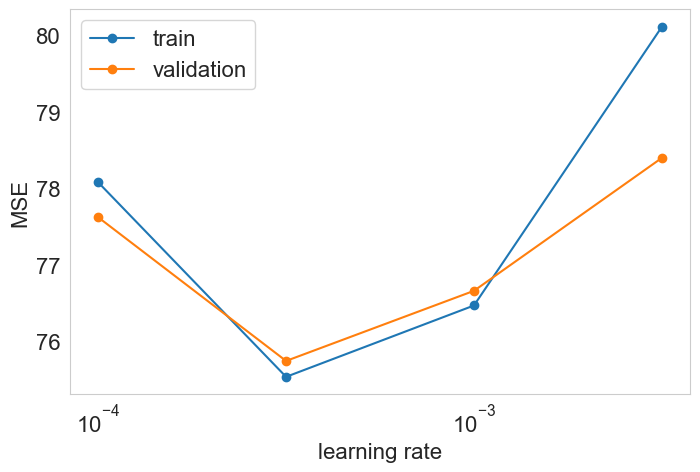

In [ ]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    learning_rates,
    train_mse_by_lr,
    marker='o',
    label='train'
)

plt.semilogx(
    learning_rates,
    val_mse_by_lr,
    marker='o',
    label='validation'
)

plt.xlabel('learning rate')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [ ]:
weight_decays = np.array([
    0.0,
    1e-6,
    1e-5,
    1e-4,
    1e-3
])

train_mse_by_weight_decay = []
val_mse_by_weight_decay = []

num_experiments = len(weight_decays)

for experiment_number, weight_decay in enumerate(
    weight_decays,
    start=1
):
    print(
        f'\nExperiment {experiment_number}/{num_experiments}'
        f'\nWeight decay: {weight_decay:.6f}'
    )

    np.random.seed(42)

    model = create_dropout_model()
    criterion = mm.MSELoss()

    optimizer = mm.Adam(
        model,
        lr=best_lr,
        weight_decay=weight_decay
    )

    train_mse, val_mse = train_and_validate(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        metric=metric_dropout,
        train_loader=train_loader_scaled,
        val_loader=val_loader_scaled,
        num_epochs=5,
        verbose=False
    )

    train_mse_by_weight_decay.append(train_mse)
    val_mse_by_weight_decay.append(val_mse)

    current_best_index = np.argmin(
        val_mse_by_weight_decay
    )
    current_best_weight_decay = weight_decays[
        current_best_index
    ]
    current_best_mse = val_mse_by_weight_decay[
        current_best_index
    ]

    print(
        f'Train MSE: {train_mse:.3f}\n'
        f'Validation MSE: {val_mse:.3f}\n'
        f'Current best weight decay: '
        f'{current_best_weight_decay:.6f}\n'
        f'Current best validation MSE: '
        f'{current_best_mse:.3f}'
    )

best_weight_decay_index = np.argmin(
    val_mse_by_weight_decay
)
best_weight_decay = weight_decays[
    best_weight_decay_index
]

print('Best weight decay:', best_weight_decay)
print(
    'Best validation MSE:',
    val_mse_by_weight_decay[best_weight_decay_index]
)

Experiment 3/5
Weight decay: 0.000010
Train MSE: 76.175
Validation MSE: 76.301
Current best weight decay: 0.000000
Current best validation MSE: 75.748
Experiment 4/5
Weight decay: 0.000100
Train MSE: 79.810
Validation MSE: 79.524
Current best weight decay: 0.000000
Current best validation MSE: 75.748
Experiment 5/5
Weight decay: 0.001000
Train MSE: 84.871
Validation MSE: 84.774
Current best weight decay: 0.000000
Current best validation MSE: 75.748
Best weight decay: 0.0
Best validation MSE: 75.74835480727629


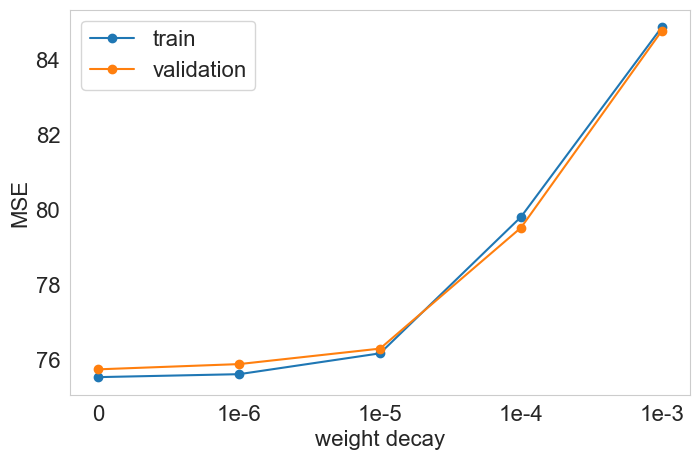

In [ ]:
positions = np.arange(len(weight_decays))
labels = ['0', '1e-6', '1e-5', '1e-4', '1e-3']

plt.figure(figsize=(8, 5))

plt.plot(
    positions,
    train_mse_by_weight_decay,
    marker='o',
    label='train'
)

plt.plot(
    positions,
    val_mse_by_weight_decay,
    marker='o',
    label='validation'
)

plt.xticks(positions, labels)
plt.xlabel('weight decay')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

### Hyperparameter search

The best tested learning rate is approximately **3.16×10⁻⁴**, with validation MSE near **75.75**. Smaller values converge too slowly under the fixed epoch budget, while larger values optimize less reliably. Weight decay does not improve the selected dropout model in this search.

## Final training on all development data

In [ ]:
X_full_train = np.concatenate([X_train, X_val], axis=0)

y_full_train = np.concatenate([y_train, y_val], axis=0)

In [ ]:
final_scaler = StandardScaler()

X_full_train_scaled = final_scaler.fit_transform(X_full_train)

X_test_scaled = final_scaler.transform(X_test)

In [ ]:
final_y_min = np.min(y_full_train)
final_y_max = np.max(y_full_train)

def normalize_final(sample):
    return (
        (sample - final_y_min)
        / (final_y_max - final_y_min)
    )

def denormalize_final(sample):
    return (
        sample * (final_y_max - final_y_min)
        + final_y_min
    )

In [ ]:
y_full_train_scaled = normalize_final(y_full_train).reshape(-1, 1)

y_test_scaled = normalize_final(y_test).reshape(-1, 1)

Validation MSE: 74.595


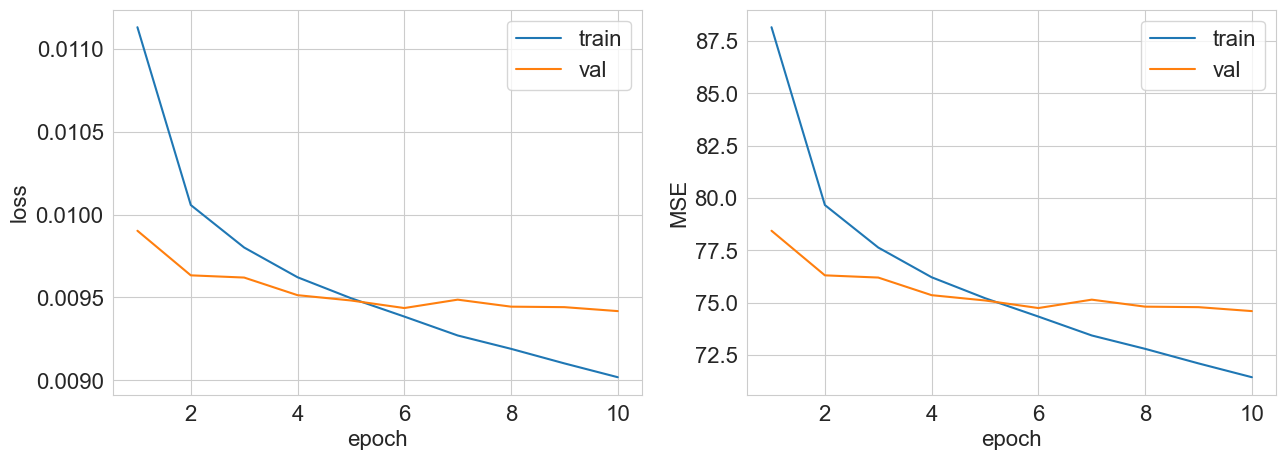

In [ ]:
batch_size = 64

full_train_loader = mm.DataLoader(
    X_full_train_scaled,
    y_full_train_scaled,
    batch_size=batch_size,
    shuffle=True
)

test_loader = mm.DataLoader(
    X_test_scaled,
    y_test_scaled,
    batch_size=batch_size,
    shuffle=False
)

np.random.seed(42)

final_model = mm.Sequential(
    mm.Linear(X_full_train_scaled.shape[1], 256),
    mm.ReLU(),
    mm.Dropout(p=0.2),

    mm.Linear(256, 256),
    mm.ReLU(),
    mm.Dropout(p=0.2),

    mm.Linear(256, 1),
    mm.Sigmoid()
)

final_criterion = mm.MSELoss()

final_optimizer = mm.Adam(
    final_model,
    lr=best_lr,
    weight_decay=best_weight_decay
)

final_metric = lambda predictions, targets: np.mean(
    (
        denormalize_final(predictions)
        - denormalize_final(targets)
    ) ** 2
)

final_train_mse, final_test_mse = train_and_validate(
    model=final_model,
    optimizer=final_optimizer,
    criterion=final_criterion,
    metric=final_metric,
    train_loader=full_train_loader,
    val_loader=test_loader,
    num_epochs=10
)

In [ ]:
print('Final neural network:')
print('Train MSE:', final_train_mse)
print('Test MSE:', final_test_mse)

print('\nBaselines:')
print('Ridge test MSE:', test_mse_ridge)
print('Constant test MSE:', test_mse_constant)

Final neural network:
Train MSE: 71.4345321239175
Test MSE: 74.59450574600517
Baselines:
Ridge test MSE: 89.74966397222087
Constant test MSE: 117.62580230734426


## Final evaluation

After refitting on the combined training and validation data, the final neural network achieves:

| Model | Test MSE |
|---|---:|
| Constant predictor | 117.63 |
| Ridge regression | 89.75 |
| NumPy neural network | **74.59** |

The final training MSE is **71.43**, so the remaining train–test gap is modest. The experiment shows that careful scaling, optimizer selection, architecture design, and regularization allow the from-scratch implementation to outperform a strong linear baseline.

## Limitations and next steps

The evaluation uses the dataset's original ordering followed by a fixed temporal-style split, matching the source benchmark setup. The reported hyperparameter comparison is intentionally compact and does not estimate uncertainty across repeated seeds. Future work could add repeated runs, confidence intervals, gradient checks in continuous integration, and comparisons with equivalent PyTorch models.